## Classification evaluation examples

In this example, we will see several methods for evaluating a classifier.

In [1]:
import numpy as np

import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'svg' 
plt.style.use('bmh')
plt.rcParams['image.cmap'] = 'Paired_r'

### Reading the breast cancer dataset

We use a dataset from the [UCI machine learning repository](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Original%29). The task is to predict whether a breast tumor is benign or malignant.

The following description was taken from the text that comes with the dataset. It describes the 9 numerical features and the coding of the output variable. (The first column is just the sample number, which we won't use.)


Data format:

1. Sample code number            (id number)
2. Clump Thickness               (1 - 10)
3. Uniformity of Cell Size       (1 - 10)
4. Uniformity of Cell Shape      (1 - 10)
5. Marginal Adhesion             (1 - 10)
6. Single Epithelial Cell Size   (1 - 10)
7. Bare Nuclei                   (1 - 10)
8. Bland Chromatin               (1 - 10)
9. Normal Nucleoli               (1 - 10)
10. Mitoses                      (1 - 10)
11. Class:                        (2 for benign, 4 for malignant)



We read the dataset using NumPy's utility function [`np.loadtxt`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.loadtxt.html) to read the CSV file.

We take out the 9 input features and put the data into the input matrix `X`. For the output `Y`, we then re-code the output variables as `benign` or `malignant` instead of the numbers used in the original file.

In [2]:
data = np.genfromtxt('breast-cancer-wisconsin.data', delimiter=',', usecols=range(1, 11))

X = data[:, 0:9]
Y = np.array([ 'malignant' if c == 4 else 'benign' for c in data[:,9] ])

In [3]:
data[:,9]

array([2., 2., 2., 2., 2., 4., 2., 2., 2., 2., 2., 2., 4., 2., 4., 4., 2.,
       2., 4., 2., 4., 4., 2., 4., 2., 4., 2., 2., 2., 2., 2., 2., 4., 2.,
       2., 2., 4., 2., 4., 4., 2., 4., 4., 4., 4., 2., 4., 2., 2., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 2., 4., 4., 2., 4., 2., 4.,
       4., 2., 2., 4., 2., 4., 4., 2., 2., 2., 2., 2., 2., 2., 2., 2., 4.,
       4., 4., 4., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 4., 4., 4., 4.,
       2., 4., 4., 4., 4., 4., 2., 4., 2., 4., 4., 4., 2., 2., 2., 4., 2.,
       2., 2., 2., 4., 4., 4., 2., 4., 2., 4., 2., 2., 2., 4., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 4., 2., 2., 2., 4., 2., 2., 4., 2., 4., 4.,
       2., 2., 4., 2., 2., 2., 4., 4., 2., 2., 2., 2., 2., 4., 4., 2., 2.,
       2., 2., 2., 4., 4., 4., 2., 4., 2., 4., 2., 2., 2., 4., 4., 2., 4.,
       4., 4., 2., 4., 4., 2., 2., 2., 2., 2., 2., 2., 2., 4., 4., 2., 2.,
       2., 4., 4., 2., 2., 2., 4., 4., 2., 4., 4., 4., 2., 2., 4., 2., 2.,
       4., 4., 4., 4., 2.

Just a quick peek at the data (first 10 instances). As you can see, the malignant instance has higher values for most features.

In [4]:
print(X[:10])
print()
print(Y[:10])

[[ 5.  1.  1.  1.  2.  1.  3.  1.  1.]
 [ 5.  4.  4.  5.  7. 10.  3.  2.  1.]
 [ 3.  1.  1.  1.  2.  2.  3.  1.  1.]
 [ 6.  8.  8.  1.  3.  4.  3.  7.  1.]
 [ 4.  1.  1.  3.  2.  1.  3.  1.  1.]
 [ 8. 10. 10.  8.  7. 10.  9.  7.  1.]
 [ 1.  1.  1.  1.  2. 10.  3.  1.  1.]
 [ 2.  1.  2.  1.  2.  1.  3.  1.  1.]
 [ 2.  1.  1.  1.  2.  1.  1.  1.  5.]
 [ 4.  2.  1.  1.  2.  1.  2.  1.  1.]]

['benign' 'benign' 'benign' 'benign' 'benign' 'malignant' 'benign'
 'benign' 'benign' 'benign']


### Training the model, basic evaluation

We split the data into training and test parts, and then train a `Pipeline` including a support vector classifier.

This example includes a [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html), which we haven't discussed previously in the course. An imputation method tries to fill in missing values in the feature matrix. In this case, if there is a missing value, the median value for that column will be substituted.

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.5, random_state=0)

np.random.seed(0)

pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LinearSVC(dual=True)
)
pipeline.fit(Xtrain, Ytrain);

The most classical evaluation metric for classifiers is the accuracy, which corresponds to the proportion of correctly classified instances. In this case, we get a fairly high accuracy.

In [6]:
from sklearn.metrics import accuracy_score

guesses = pipeline.predict(Xtest)

accuracy_score(Ytest, guesses)

0.9542857142857143

### Evaluation metrics based on a confusion matrix

A [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix) is such that the cell at row $i$ and column $j$ is equal to the number of observations known to be in group $i$ but predicted to be in group $j$.

For instance, in this case, 5 instances were malignant but were classified as benign, while 11 were benign and classified as malignant. (Note the order: benign comes before malignant in the matrix.)


In [7]:
from sklearn.metrics import confusion_matrix

print(pipeline.classes_)
print()

# rows: gold standard class
# columns: predicted class
print(confusion_matrix(Ytest, guesses))


['benign' 'malignant']

[[209  11]
 [  5 125]]


Several metrics can be derived from a confusion matrix. (See the [Wikipedia article](https://en.wikipedia.org/wiki/Confusion_matrix).) In particular, they tend to be based on the special case of a confusion matrix, where we assign one class to be the "positive" class that is important to us: the "needle" we are looking for in the "haystack". This is sometimes called a [table of confusion](https://en.wikipedia.org/wiki/Confusion_matrix#Table_of_confusion). In such a table, we speak of *true positives*, *false positives*, *false negatives*, and *true negatives*.

The [precision and recall](https://en.wikipedia.org/wiki/Precision_and_recall) metrics are probably the most common metrics derived from such a table. 

* $P$ = TP / (TP + FP)

* $R$ = TP / (TP + FN)

Here is how we compute precision and recall values. We specify that the "needles" we are looking for are the malignant tumors. 

In [8]:
from sklearn.metrics import precision_score, recall_score

print(precision_score(Ytest, guesses, pos_label='malignant'), recall_score(Ytest, guesses, pos_label='malignant'))

0.9191176470588235 0.9615384615384616


The utility function [`classification_report`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) prints the precision and recall values for all the categories. (The $F_1$ score is the harmonic mean of the precision and recall.)

In [9]:
from sklearn.metrics import classification_report

print(classification_report(Ytest, guesses))

              precision    recall  f1-score   support

      benign       0.98      0.95      0.96       220
   malignant       0.92      0.96      0.94       130

    accuracy                           0.95       350
   macro avg       0.95      0.96      0.95       350
weighted avg       0.96      0.95      0.95       350



### Plotting the data and the classifier's decision boundary

Before discussing precision/recall curves below, it can be useful to visualize the data and the classifier's decision boundary.

We reuse the function from Lecture 3 that plots the decision boundary of a classifier.

In [10]:
def encode_y(Y, classes):
    return np.array([ -1 if y == classes[0] else 1 for y in Y ])

def plot_boundary(clf, X, Y):
    h = 0.02
    x_min, x_max = X[:,0].min() - 10*h, X[:,0].max() + 10*h
    y_min, y_max = X[:,1].min() - 10*h, X[:,1].max() + 10*h
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = encode_y(clf.predict(np.c_[xx.ravel(), yy.ravel()]), clf.classes_)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(5,5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.contour(xx, yy, Z, colors='k', linewidths=0.7)
    Ym = encode_y(Y, clf.classes_)
    plt.scatter(X[:,0], X[:,1], c=Ym, edgecolors='k');

In order to be able to make a two-dimensional visualization, we apply a feature selector that selects the two "best" features. We then train a SVC and plot its decision boundary.

(Note: I happen to know that features 2 and 6 were selected in this case: that's why I could use descriptive x and y labels.)

Take a look at the line that separates the classifier's idea of the two classes. What happens (in terms of precision and recall) if we move the line in one direction or the other?

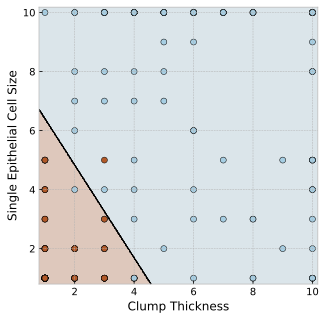

In [11]:
preproc_pipeline = make_pipeline(
        SimpleImputer(strategy='median'),
        SelectKBest(k=2),
)
Xtrain_f = preproc_pipeline.fit_transform(Xtrain, Ytrain)

clf = LinearSVC(dual=True)

clf.fit(Xtrain_f, Ytrain)
plot_boundary(clf, Xtrain_f, Ytrain)
plt.xlabel('Clump Thickness')
plt.ylabel('Single Epithelial Cell Size');

### Rank-based evaluation of the classifier

What if we'd like to evaluate the classifier's decision function scores in terms of *ranking*? That is, we'd like the decision function to score malignant tumors higher than benign tumors.

Let's go back to the classification problem discussed above. We apply the classifier's decision function (that is, $w\cdot x$) to all the instances in the test set, and we rank the instances from high to low. We then print the top 10 and bottom 10 of this list. From what we can see from this small part of the ranked list, this seems to be a good ranking because the malignant tumors are at the beginning and the benign tumors at the end.

If you experiment a bit by adding random noise to the output of the decision function, we get rankings of lower quality.

In [12]:
from pprint import pprint

scores = pipeline.decision_function(Xtest)

# uncomment this if you want to add random noise to mess up the ranking
#scores += 5*np.random.normal(size=scores.shape)

ranked_list = sorted(zip(scores, Ytest), reverse=True)

pprint(ranked_list[:10])
print()
pprint(ranked_list[-10:])

[(8.17831218781175, 'malignant'),
 (8.05483206111334, 'malignant'),
 (7.951446288251398, 'malignant'),
 (7.371517271175226, 'malignant'),
 (7.3082380954302915, 'malignant'),
 (7.237449020611281, 'malignant'),
 (7.188040905027638, 'malignant'),
 (7.053100943058511, 'malignant'),
 (6.807419615707104, 'malignant'),
 (6.759382652157357, 'malignant')]

[(-2.853104827737406, 'benign'),
 (-2.853104827737406, 'benign'),
 (-2.853104827737406, 'benign'),
 (-2.853104827737406, 'benign'),
 (-2.853104827737406, 'benign'),
 (-2.853104827737406, 'benign'),
 (-2.853104827737406, 'benign'),
 (-2.853104827737406, 'benign'),
 (-2.9158682626387424, 'benign'),
 (-2.9158682626387424, 'benign')]


One way to evaluate ranking systems is to use a *precision/recall* curve. The idea is that we'd like to investigate the precision/recall tradeoff over all possible thresholds. That is, in the plot of the decision boundary, imagine that we move the boundary from the bottom left to the top right and think of what happens.

Good P/R curves are near the upper right corner. In this case (because it seems to be a fairly easy classificaion problem) the P/R curve is nearly perfect.

Again, you can see what happens if you make the ranking worse by adding noise to the decision function. In this case, the P/R curve moves down. (The more noise you add, the more the curve moves down.)

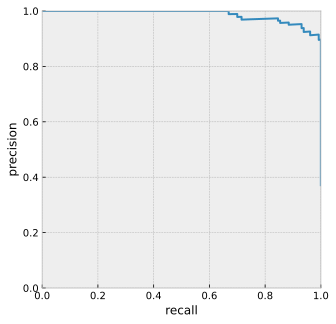

In [13]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

scores = pipeline.decision_function(Xtest)

# uncomment this if you want to add random noise to mess up the ranking
#scores += 5*np.random.normal(size=scores.shape)

precs, recs, _ = precision_recall_curve(Ytest, scores, pos_label='malignant')

plt.figure(figsize=(5,5))
plt.plot(recs, precs)
plt.xlabel('recall')
plt.ylabel('precision')
plt.axis([0, 1, 0, 1]);

The [average precision](https://en.wikipedia.org/wiki/Information_retrieval#Average_precision) summarizes the precision/recall curve as a single number. It is the area under the curve. For a perfect system, the AP score would be 1.0, so you can see that our score is very good.

In [14]:
average_precision_score(Ytest, scores, pos_label='malignant')

0.986163811415405

In the following example, we will compare three different systems using P/R curves.

We first train the three classifiers, which are all linear SVCs. The difference between the classifiers is in the number of features that they use: 1, 2 or all 9 features. We use a feature selector to pick out a subset of features.

In [15]:
pipelines = []
for n_features in [1, 2, 'all']:
    pipeline = make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler(),
        SelectKBest(k=n_features),
        LinearSVC(dual=True)
    )
    pipeline.fit(Xtrain, Ytrain)
    pipelines.append((n_features, pipeline))

We compare the three systems using precision/recall curves. As you can see, the 9-feature classifier is slightly better than the 2-feature classifier, which in turn is quite a bit better than the 1-feature classifier.

We also show the average precision values for all three classifiers.

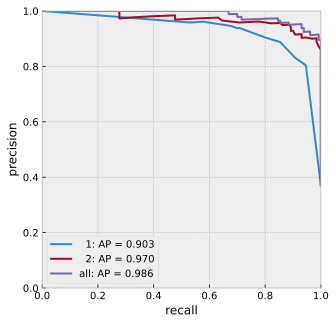

In [16]:
APs = []
plt.figure(figsize=(5,5))
for n_features, pipeline in pipelines:
    scores = pipeline.decision_function(Xtest)
    precisions, recalls, _ = precision_recall_curve(Ytest, scores, pos_label='malignant')
    
    plt.plot(recalls, precisions)
    plt.xlabel('recall')
    plt.ylabel('precision')
    APs.append((n_features, average_precision_score(Ytest, scores, pos_label='malignant')))
    
leg_labels = [ '{:3}: AP = {:.3f}'.format(n, AP) for n, AP in APs ]
plt.legend(leg_labels);
plt.axis([0, 1, 0, 1]);

An alternative to the precision/recall curve used in some research fields is the [ROC curve](https://en.wikipedia.org/wiki/Receiver_operating_characteristic), which compares the true positive rate and false positive rate for different thresholds.

A good ROC curve is near the top left corner, while the ROC curve for a useless classifier is diagonal.

Just like for the P/R curve, there is a metric that summarizes the curve as a single number. For ROC curve, this metric is called AUC (Area Under Curve).

0.9923076923076923

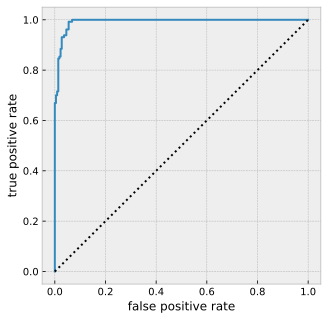

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

fprs, tprs, _ = roc_curve(Ytest, scores, pos_label='malignant')

plt.figure(figsize=(5,5))

plt.plot(fprs, tprs)

plt.plot([0, 1], 'k:')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')

roc_auc_score(Ytest=='malignant', scores)

### Use of different evaluation scores in cross-validation

All the scoring schemes we have discussed here can be used in cross-validation, grid search for parameters, etc. [This page](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter) lists a number of pre-defined scorers corresponding to evaluation procedures we have seen. For instance, `accuracy` is the accuracy, `average_precision` is the average precision, `roc_auc` is the area under the ROC curve.

Let's see how we can use the average precision in a cross-validation. If your outputs are already numerically coded, we can just use the pre-defined argument `average_precision` mentioned above. However, in our case it's a bit kludgier because we need to say that the malignant tumors are the "needles in the haystack", so we need to pass the `pos_label='malignant'` argument. To pass this argument, we need to make a scorer object using `make_scorer`.
See the [`documentation`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html) of this function for more details.

The scorer object returned by `make_scorer` can now be passd to `cross_val_score`. This will now help us compute the average precision for each fold in the cross-validation.

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

ap_malignant = make_scorer(average_precision_score, pos_label='malignant', needs_threshold=True)

print(cross_val_score(pipeline, X, Y, cv=5, scoring=ap_malignant))

[0.97492197 0.97662067 0.99308457 0.99917534 0.99831633]
